# Домашнее задание к занятию «Проблема качества данных»

Выполнил: Ярослав Золотухин

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv( 'train.csv' )
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Удаляю все пропущенные значения и категориальные переменные

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
selectedColumns = data[ [ 'PassengerId', 'Pclass', 'Age', 'SibSp',  'Parch', 'Fare','Survived' ] ]

selectedColumns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Age          714 non-null    float64
 3   SibSp        891 non-null    int64  
 4   Parch        891 non-null    int64  
 5   Fare         891 non-null    float64
 6   Survived     891 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 48.9 KB


In [5]:
selectedColumns['Age'].unique()

array([22.  , 38.  , 26.  , 35.  ,   nan, 54.  ,  2.  , 27.  , 14.  ,
        4.  , 58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  , 28.  ,
        8.  , 19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  ,
       49.  , 29.  , 65.  , 28.5 ,  5.  , 11.  , 45.  , 17.  , 32.  ,
       16.  , 25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  ,
       71.  , 37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 ,
       51.  , 55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  ,
       45.5 , 20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  ,
       60.  , 10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  ,
       70.  , 24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

In [6]:
for col in selectedColumns.columns:
    selectedColumns = selectedColumns.drop(selectedColumns[pd.isnull( selectedColumns['Age'])].index)

selectedColumns.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  714 non-null    int64  
 1   Pclass       714 non-null    int64  
 2   Age          714 non-null    float64
 3   SibSp        714 non-null    int64  
 4   Parch        714 non-null    int64  
 5   Fare         714 non-null    float64
 6   Survived     714 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 44.6 KB


In [7]:
# тут я просто убедился, что значения действительно только 0 и 1 и что никаких манипуляций с этим столбцом делать не нужно
selectedColumns['Survived'].unique()

array([0, 1])

### Обучаю модель на полученном датасете

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = selectedColumns[ [ 'PassengerId', 'Pclass', 'Age', 'SibSp',  'Parch', 'Fare'] ]
X.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
0,1,3,22.0,1,0,7.2500
1,2,1,38.0,1,0,71.2833
2,3,3,26.0,0,0,7.9250
3,4,1,35.0,1,0,53.1000
4,5,3,35.0,0,0,8.0500


In [9]:
y = selectedColumns['Survived']
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [11]:
model = LogisticRegression()
model.fit( X_train, y_train )

LogisticRegression()

In [12]:
y_pred = model.predict(X_test)

In [13]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1-Score: {f1}")

F1-Score: 0.6949578454216202


## Снова загружаем данные и анализируем их

In [14]:
data_2 = pd.read_csv( 'train.csv' )
data_2.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


ID пассажира, ФИО и номер билета не несут никакой ценности для построения модели, т.к. значения каждой строчки по этим столбцам уникальны.
<br>
Номер кабины имеет слишком большое количество показателей, много пропусков, что плохо отразится на модели, поэтому этот показатель мы тоже уберем.

In [15]:
data_2['Pclass'].corr(data_2['Fare'])

np.float64(-0.5494996199439078)

Выше я проверил корреляцию между классом каюты и стоимостью билета (что логично). Но как мы видим из результата - связь не сильная, поэтому можно использовать оба показателя для модели.

### Убираем ненужные столбцы

In [16]:
selectedColumns_2 = data[ [ 'Pclass', 'Sex', 'Age', 'SibSp',  'Parch', 'Fare', 'Embarked', 'Survived' ] ]

selectedColumns_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       714 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  889 non-null    object 
 7   Survived  891 non-null    int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


Если мы удалим пропуски, то мы потеряем $$ 1 - (714/891)*100 \approx 20 \% $$ что является довольно существенными потерями. Поэтому для заполнения пустых значений для возраста возьмем среднее арифметическое, а для столбца Embarked укажем значение "Unknown"
<br>
Хотя возможно датасет можно было и отфильтровать по пустым значениям Embarked, т.к. пустых значений всего лишь два

In [17]:
avg_age = np.mean(selectedColumns_2['Age']).round()

selectedColumns_2['Age'] = selectedColumns_2['Age'].fillna(avg_age)
selectedColumns_2['Embarked'] = selectedColumns_2['Embarked'].fillna('Unknown')

selectedColumns_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       891 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  891 non-null    object 
 7   Survived  891 non-null    int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


/var/folders/6w/fwb_07rx7c3_dpz1j_x3zv880000gn/T/ipykernel_4937/2019728638.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selectedColumns_2['Age'] = selectedColumns_2['Age'].fillna(avg_age)
/var/folders/6w/fwb_07rx7c3_dpz1j_x3zv880000gn/T/ipykernel_4937/2019728638.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selectedColumns_2['Embarked'] = selectedColumns_2['Embarked'].fillna('Unknown')


Для наших категориальных переменных будем использовать функцию get_dummies, потому что категории внутри Sex и Embarked равнозначны между собой и имеют небольшое количество категорий.

In [18]:
X_2 = pd.get_dummies( selectedColumns_2, columns = [ 'Sex', 'Embarked' ] )

X_2.head()

,Pclass,Age,SibSp,Parch,Fare,Survived,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Embarked_Unknown
0,3,22.0,1,0,7.2500,0,False,True,False,False,True,False
1,1,38.0,1,0,71.2833,1,True,False,True,False,False,False
2,3,26.0,0,0,7.9250,1,True,False,False,False,True,False
3,1,35.0,1,0,53.1000,1,True,False,False,False,True,False
4,3,35.0,0,0,8.0500,0,False,True,False,False,True,False


Прежде чем проверять показатели на выбросы, визуализируем их.

(array([838.,  33.,  17.,   0.,   3.]),
 array([  0.     , 102.46584, 204.93168, 307.39752, 409.86336, 512.3292 ]),
 <BarContainer object of 5 artists>)

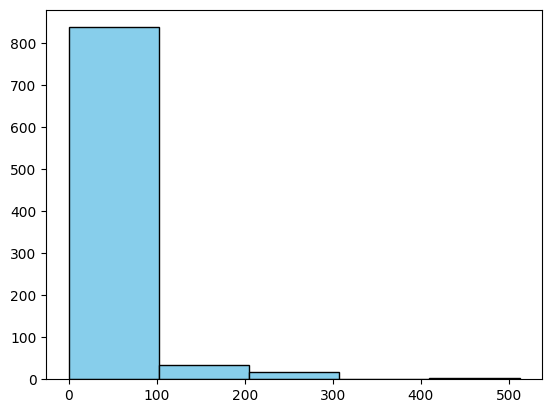

In [19]:
plt.hist(X_2['Fare'], bins=5, color='skyblue', edgecolor='black')

Как видно из визуализации, в столбце Fare присутствуют явные выбросы в диапазоне 400-500.

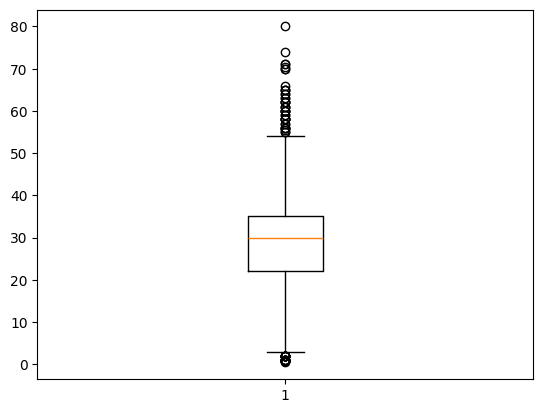

In [20]:
plt.boxplot(X_2['Age'])
plt.show()

В поле Age тоже присутствуют выбросы, которые отображены на графике "Ящик с усами" точками.

Для проверки данных на наличие выбросов используем метод межквартильного размаха (IQR). Метод основан на расчёте квартилей и определении границ нормальных значений. 
<br>
Выбросами считаются значения ниже Q1 − 1,5 × IQR или выше Q3 + 1,5 × IQR.
<br>
Ниже представлен пример функции, реализующий данный метод.

In [21]:
def iqr_filter(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

X_2 = iqr_filter(X_2, 'Age')
X_2 = iqr_filter(X_2, 'Fare')

X_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 718 entries, 0 to 890
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Pclass            718 non-null    int64  
 1   Age               718 non-null    float64
 2   SibSp             718 non-null    int64  
 3   Parch             718 non-null    int64  
 4   Fare              718 non-null    float64
 5   Survived          718 non-null    int64  
 6   Sex_female        718 non-null    bool   
 7   Sex_male          718 non-null    bool   
 8   Embarked_C        718 non-null    bool   
 9   Embarked_Q        718 non-null    bool   
 10  Embarked_S        718 non-null    bool   
 11  Embarked_Unknown  718 non-null    bool   
dtypes: bool(6), float64(2), int64(4)
memory usage: 43.5 KB


Для выполнения пункта 9 домашнего задания возведем в квадрат столбец Age. Это может помочь линейной модели обучаться лучше, т.к. возникнут степенные связи, если возвести признак в степень.

In [22]:
X_2['Age'] = X_2['Age']**2

## Обучаем модель по преобразованному датасету

In [23]:
y_2 = X_2['Survived']

del X_2['Survived']

y_2.head()

0    0
2    1
3    1
4    0
5    0
Name: Survived, dtype: int64

In [24]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.3, random_state=42)

In [25]:
model_2 = LogisticRegression()
model_2.fit( X_train_2, y_train_2 )

/Users/acer/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [26]:
y_pred_2 = model_2.predict(X_test_2)

In [27]:
f1_2 = f1_score(y_test_2, y_pred_2, average='weighted')
print(f"F1-Score: {f1_2}")

F1-Score: 0.7934433032472249


# Выводы по проделанной работе

В ходе данного домашнего задания был выполнен анализ файла train.csv (test.csv не использовался в данном домашнем задании, т.к. в нем отсутсвовал столбец Survived по которому можно было бы оценить качество модели)
<br>
1. В первом случае для обучения модели использовался датасет только с численными переменными с вычетом пропуском. Значение F1 для данного случая оказалось равным 0,69, что показывает то, что данная модель плохо предсказывает выживших.
2. Во втором случае были удалены столбцы с уникальными значениями и с большим количеством пропусков. Для столбца Age вместо пропусков были указаны средне-арифметические значения, а для пропусков в столбце Embarked добавлена категория "Unknown". После этого был проведен анализ данных на выбросы, которые были отображены на графиках "Гистограмма" и "Ящик с усами" соответственно. После вышеописанных мероприятий, модель, обученная на обработанном датасете дала лучше результат 
<br>

| Датасет | F-1 |
|--------|---------------|
| Первый случай | 0.6949 |
| Второй случай | 0.7934 |

<br>
Исходя из представленных значений F-1, можем сделать вывод о том, что обработка данных помогла добиться лучшего качества модели.
<br>
Отсюда напрашивается вывод, что предобработка данных действительно необходимый шаг перед построением модели и занимает большую часть времени работы ML-инженера. 
<br>
На больших данных предобработка данных также необходима, но подходы к исследованию данных меняются. Например, из большого количества данных обычно анализ одного из сэмплов достаточен для получения полноценной картины. Пропуски логичнее в таких случаях выводить в отдельную категорию, либо задавать константой, т.к. пропуск на больших данных является сигналом для бизнеса, который интерпретируется в зависимости от контекста.